 # Loan Eligibility Prediction using Random Forest classifier 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

In [2]:
df = pd.read_csv("Loan Eligibility Prediction.csv")

In [3]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [5]:
df.shape

(614, 13)

In [6]:
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


### Step 3 EDA

In [7]:
df.isnull().sum()

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop("Customer_ID", axis=1, inplace=True)

In [11]:
#encoding
encoders = {}

categorical_columns = [

    "Gender",

    "Married",

    "Dependents",

    "Education",

    "Self_Employed",

    "Property_Area",

    "Loan_Status"

]

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

#loan status countplot
sns.countplot(x="Loan_Status",data=df)

plt.show()

### Step 4 Target Variable

In [13]:
X = df.drop("Loan_Status",axis=1)

y = df["Loan_Status"]

In [24]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,0,0,2378,0.0,9,360,1,2,0
1,1,1,2,0,0,1299,1086.0,17,120,1,2,1
2,1,0,0,1,0,3620,0.0,25,120,1,1,1
3,1,1,0,0,1,3459,0.0,25,120,1,1,1
4,1,1,1,0,0,5468,1032.0,26,360,1,1,1


### Step 5 Train Test Split

In [14]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y
)

In [15]:
model = RandomForestClassifier(

n_estimators=100,

random_state=42

)

In [16]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred=model.predict(X_test)

In [18]:
print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.7723577235772358


In [19]:
print("Precision :",precision_score(y_test,y_pred))

Precision : 0.7938144329896907


In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.47      0.56        38
           1       0.79      0.91      0.85        85

    accuracy                           0.77       123
   macro avg       0.74      0.69      0.70       123
weighted avg       0.76      0.77      0.76       123



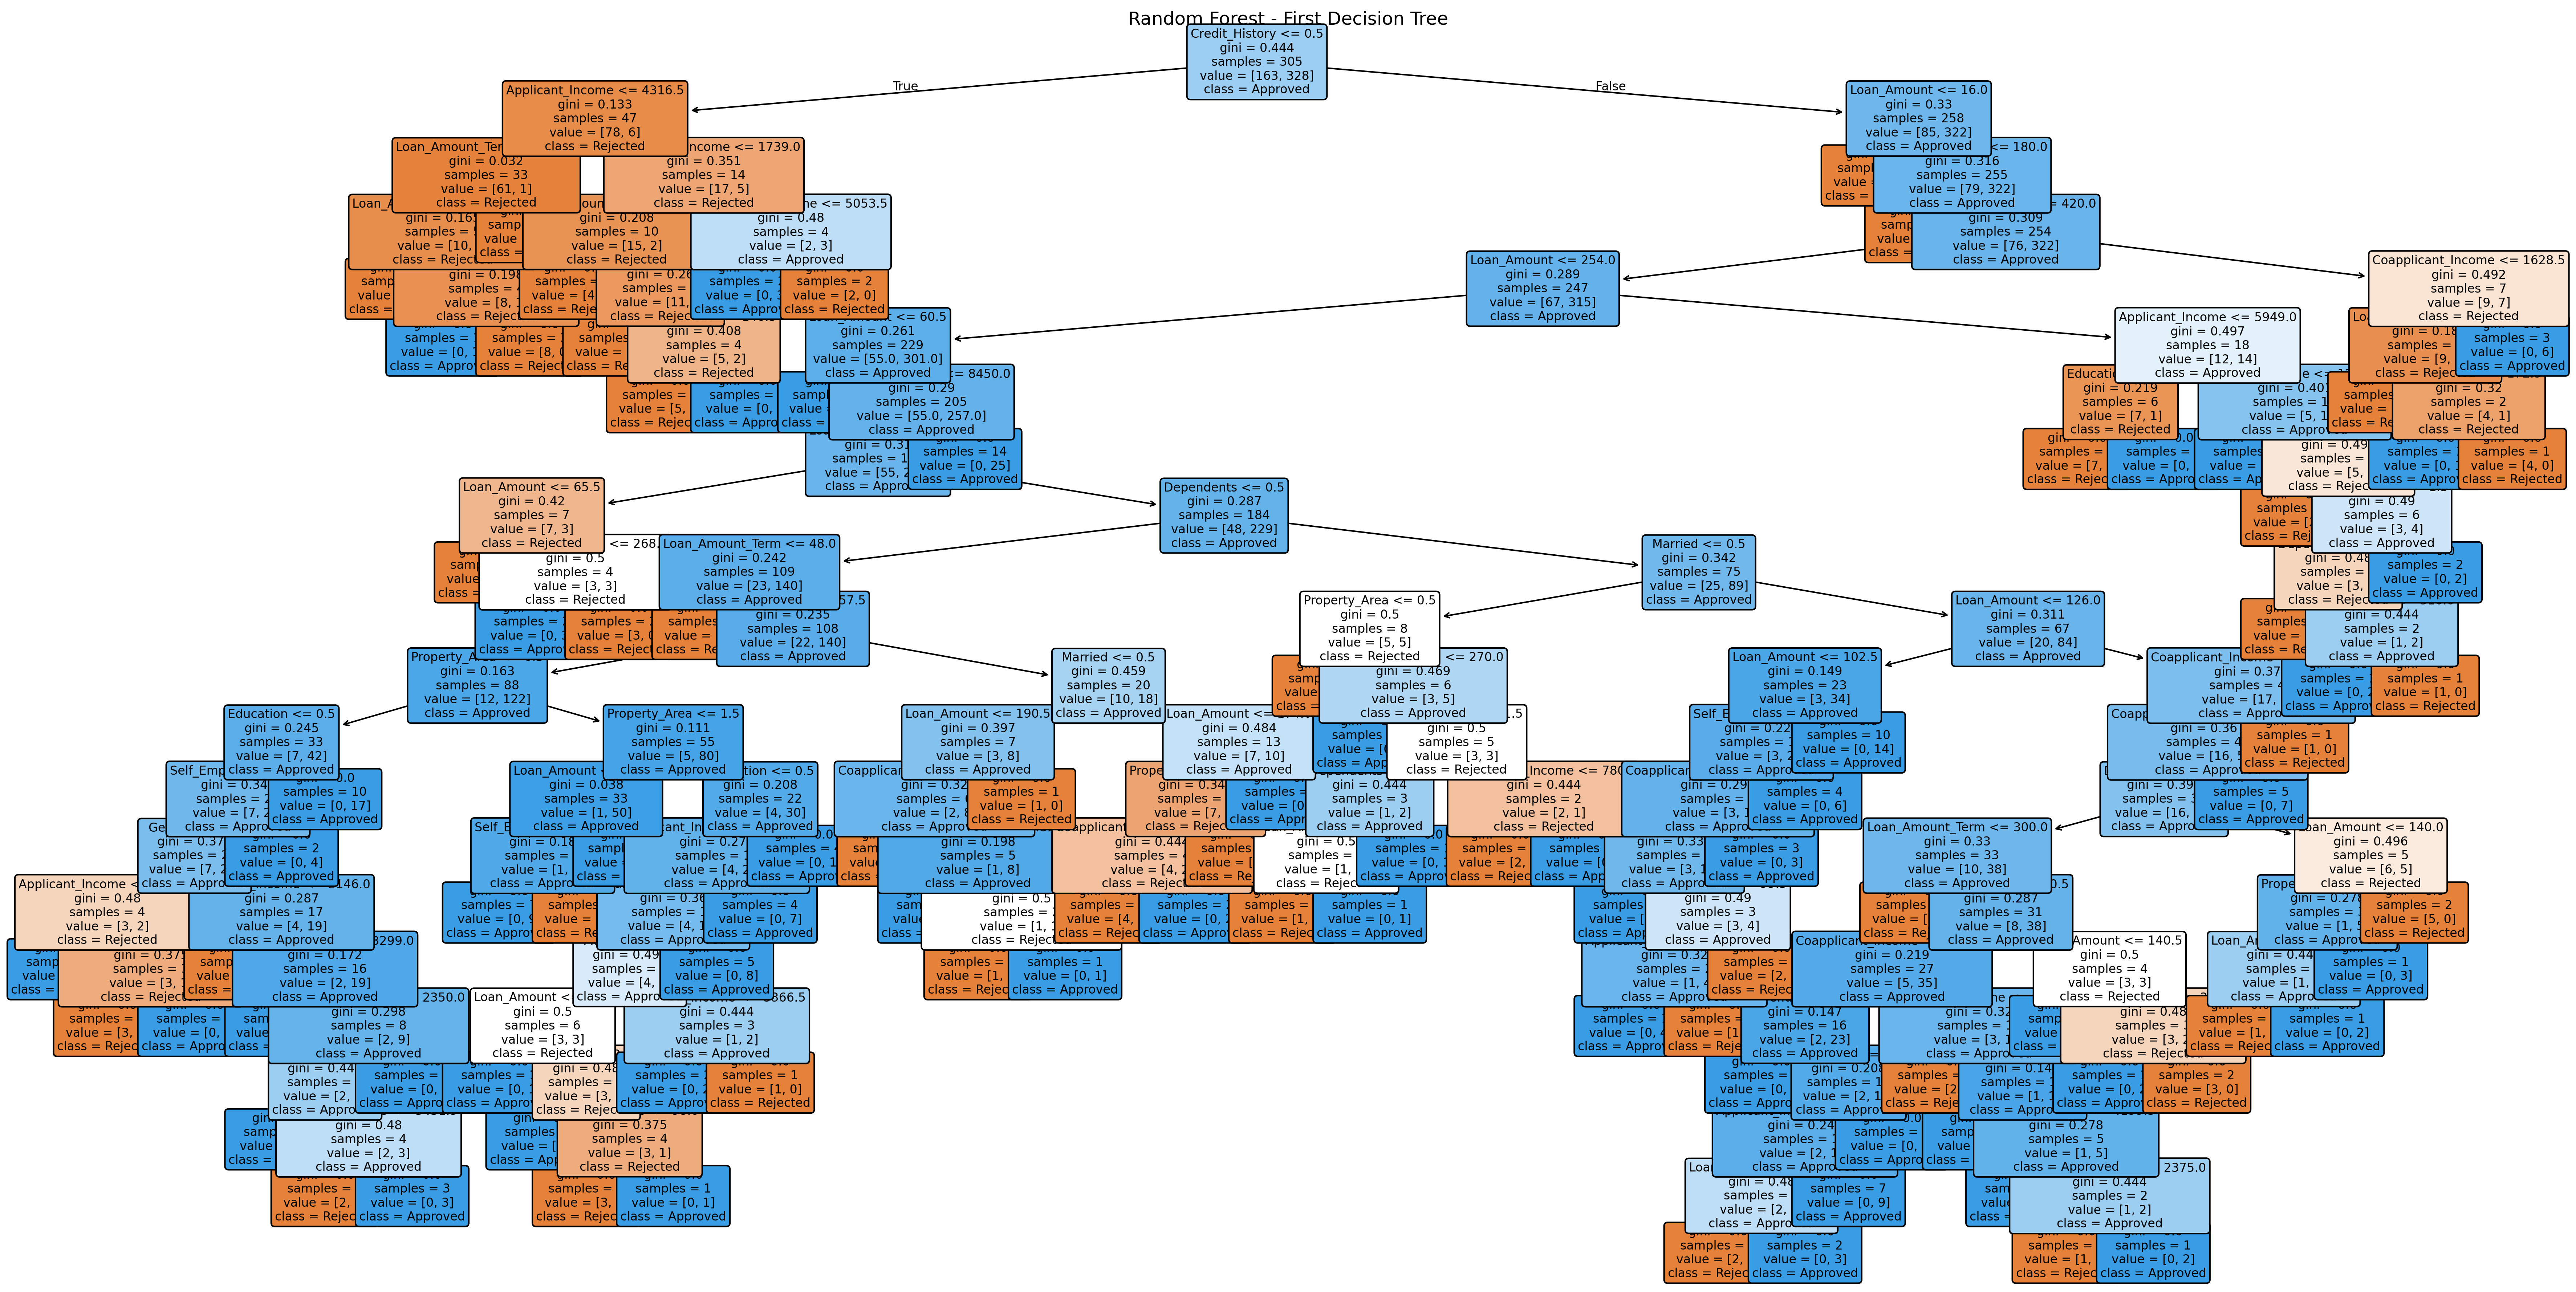

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12),dpi=300)

plot_tree(

model.estimators_[0],

feature_names=X.columns,

class_names=["Rejected","Approved"],

filled=True,

rounded=True,

fontsize=8

)

plt.title("Random Forest - First Decision Tree")

plt.tight_layout()

plt.show()

In [22]:
artifacts={

    "model":model,

    "encoders":encoders

}

pickle.dump(

artifacts,

open("artifacts.pkl","wb")
)